In [42]:
%cd /content

/content


In [43]:
!apt-get -qq update
!apt-get -qq install -y tesseract-ocr
!pip -q install pytesseract pillow opencv-python pandas jiwer tqdm

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [44]:
!git clone --depth 1 https://github.com/ehs9nino/LoREx-160.git

fatal: destination path 'LoREx-160' already exists and is not an empty directory.


Paths + load ground truth (train.json)

In [45]:
import json, re
from pathlib import Path

DATASET_ROOT = Path("/content/LoREx-160/rate_confirmations")
ANN_PATH = DATASET_ROOT / "annotations" / "train.json"
IMG_DIR  = DATASET_ROOT / "images" / "train"

print("ANN exists:", ANN_PATH.exists())
print("IMG dir exists:", IMG_DIR.exists())

gt = json.loads(ANN_PATH.read_text(encoding="utf-8"))
print("Total train records:", len(gt))
print("First record keys:", gt[0].keys())

ANN exists: True
IMG dir exists: True
Total train records: 120
First record keys: dict_keys(['source_image', 'load_number', 'pickup_location', 'pickup_time', 'dropoff_location', 'dropoff_time', 'total_rate', 'rate_per_mile'])


OCR (Tesseract) helper

In [46]:
import pytesseract
from PIL import Image

def ocr_tesseract(img_path: Path) -> str:
    img = Image.open(img_path).convert("RGB")
    # psm 6 = assume a block of text; works decently for screenshots
    return pytesseract.image_to_string(img, config="--oem 3 --psm 6")

Regex extractor (7 fields)

In [47]:
def extract_regex_fields(text: str) -> dict:
    out = {
        "load_number": "",
        "pickup_location": "",
        "pickup_time": "",
        "dropoff_location": "",
        "dropoff_time": "",
        "total_rate": "",
        "rate_per_mile": "",
    }

    t = text.replace("\n", " ").replace("\t", " ")
    t = re.sub(r"\s+", " ", t).strip()

    # Load number like 116WQ2Q4S or T-1144GWBNN (tune if needed)
    m = re.search(r"\bT-\d{3,}[A-Z0-9]{3,}\b|\b\d{3}[A-Z0-9]{5,}\b", t)
    if m:
        out["load_number"] = m.group(0)

    # Money: total rate ($1 022,07 or $1,022.07 or $1022.07)
    money = re.findall(r"\$\s?\d[\d\s,\.]*", t)
    if money:
        out["total_rate"] = money[0].replace(" ", "")

    # rate per mile
    rpm = re.search(r"\$\s?\d[\d,\.]*\s*/\s*mi", t, flags=re.I)
    if rpm:
        out["rate_per_mile"] = re.sub(r"\s+", "", rpm.group(0))

    # Locations (simple heuristic: lines with CITY, ST ZIP)
    locs = re.findall(r"\b[A-Z0-9]{2,5}\s+[A-Z][A-Z\s]+,\s*[A-Z]{2}\s*\d{5}\b", t)
    if len(locs) >= 1: out["pickup_location"] = locs[0]
    if len(locs) >= 2: out["dropoff_location"] = locs[1]

    # Times (heuristic)
    times = re.findall(r"\b(?:Mon|Tue|Wed|Thu|Fri|Sat|Sun)[a-z]*,\s*[A-Za-z]{3}\s*\d{1,2},\s*\d{1,2}:\d{2}\s*(?:AM|PM)?\s*(?:EDT|EST|CDT|CST|MDT|MST|PDT|PST)?\b", t)
    if len(times) >= 1: out["pickup_time"] = times[0]
    if len(times) >= 2: out["dropoff_time"] = times[1]

    return out

Metrics (WER/CER per field)

In [48]:
from jiwer import wer, cer

FIELDS = ["load_number","pickup_location","pickup_time","dropoff_location","dropoff_time","total_rate","rate_per_mile"]

def norm(s: str) -> str:
    s = (s or "").strip().lower()
    s = re.sub(r"\s+", " ", s)
    return s

def field_metrics(gt_val: str, pred_val: str) -> dict:
    return {"wer": float(wer(norm(gt_val), norm(pred_val))), "cer": float(cer(norm(gt_val), norm(pred_val)))}

Run on 10 samples + save CSV/JSON

In [49]:
import json
import pandas as pd
from pathlib import Path
from tqdm import tqdm

# --- config ---
N = 10
subset = gt[:N]

IMG_ROOT = Path("/content/LoREx-160/rate_confirmations/images")
SPLITS = ["train", "val", "test"]
EXTS = [".jpg", ".jpeg", ".png"]

def find_image_path(filename: str) -> Path:
    """
    Find an image in train/val/test even if extension differs.
    Example input: '17.jpg' or '17.png'
    """
    stem = Path(filename).stem  # '17'
    # try exact first (in case annotation already correct)
    for sp in SPLITS:
        p = IMG_ROOT / sp / filename
        if p.exists():
            return p

    # try alternate extensions
    for sp in SPLITS:
        for ext in EXTS:
            p = IMG_ROOT / sp / f"{stem}{ext}"
            if p.exists():
                return p

    # debugging help
    raise FileNotFoundError(
        f"Could not find {filename} (stem={stem}) under {IMG_ROOT}/(train|val|test) with exts {EXTS}"
    )

rows = []
for rec in tqdm(subset):
    img_path = find_image_path(rec["source_image"])   # ✅ robust
    text = ocr_tesseract(img_path)
    pred = extract_regex_fields(text)

    row = {"image": img_path.name, "split_path": str(img_path)}
    for f in FIELDS:
        g = rec.get(f, "")
        p = pred.get(f, "")
        m = field_metrics(g, p)
        row[f"gt_{f}"] = g
        row[f"pred_{f}"] = p
        row[f"WER_{f}"] = m["wer"]
        row[f"CER_{f}"] = m["cer"]
    rows.append(row)

df = pd.DataFrame(rows)
display(df[["image"] + [f"WER_{f}" for f in FIELDS] + [f"CER_{f}" for f in FIELDS]])

avg = {f"WER_{f}": float(df[f"WER_{f}"].mean()) for f in FIELDS}
avg.update({f"CER_{f}": float(df[f"CER_{f}"].mean()) for f in FIELDS})

print("\nAverages on 10 samples:")
for k, v in avg.items():
    print(k, "=", v)

OUT_DIR = Path("/content/results")
OUT_DIR.mkdir(parents=True, exist_ok=True)
df.to_csv(OUT_DIR / "regex_tesseract_10.csv", index=False)
(OUT_DIR / "regex_tesseract_10_avg.json").write_text(json.dumps(avg, indent=2), encoding="utf-8")
print("\nSaved to:", OUT_DIR)
print("Files:", list(OUT_DIR.iterdir()))

100%|██████████| 10/10 [00:19<00:00,  1.97s/it]


,image,WER_load_number,WER_pickup_location,WER_pickup_time,WER_dropoff_location,WER_dropoff_time,WER_total_rate,WER_rate_per_mile,CER_load_number,CER_pickup_location,CER_pickup_time,CER_dropoff_location,CER_dropoff_time,CER_total_rate,CER_rate_per_mile
0,17.jpg,1.0,1.0,0.6,1.00,1.0,0.0,0.0,1.000000,1.0,0.285714,1.0,1.0,0.000000,0.000
1,18.jpg,0.0,1.0,0.4,1.00,0.0,1.0,0.0,0.000000,1.0,0.238095,1.0,0.0,0.100000,0.000
2,19.png,1.0,1.0,1.0,1.00,1.0,1.0,1.0,0.111111,1.0,1.000000,1.0,1.0,0.111111,1.000
3,20.png,1.0,1.0,1.0,1.00,1.0,0.0,1.0,0.111111,1.0,1.000000,1.0,1.0,0.000000,1.000
4,21.png,1.0,1.0,1.0,1.00,1.0,1.0,1.0,1.000000,1.0,1.000000,1.0,1.0,0.142857,1.000
5,22.jpg,0.0,1.0,0.0,1.00,0.0,1.0,0.0,0.000000,1.0,0.000000,1.0,0.0,0.166667,0.000
6,23.png,0.0,1.0,0.2,1.00,0.0,1.0,0.0,0.000000,1.0,0.045455,1.0,0.0,0.111111,0.000
7,24.png,1.0,1.0,1.0,1.00,1.0,1.0,1.0,0.250000,1.0,1.000000,1.0,1.0,1.000000,1.000
8,25.png,0.0,0.0,1.0,1.25,1.0,1.0,1.0,0.000000,0.0,1.000000,0.8,1.0,0.166667,0.250
9,26.png,1.0,1.0,0.0,1.00,0.0,1.0,1.0,0.090909,1.0,0.000000,1.0,0.0,0.111111,0.125



Averages on 10 samples:
WER_load_number = 0.6
WER_pickup_location = 0.9
WER_pickup_time = 0.62
WER_dropoff_location = 1.025
WER_dropoff_time = 0.6
WER_total_rate = 0.8
WER_rate_per_mile = 0.6
CER_load_number = 0.2563131313131313
CER_pickup_location = 0.9
CER_pickup_time = 0.5569264069264068
CER_dropoff_location = 0.9800000000000001
CER_dropoff_time = 0.6
CER_total_rate = 0.19095238095238096
CER_rate_per_mile = 0.4375

Saved to: /content/results
Files: [PosixPath('/content/results/regex_tesseract_10.csv'), PosixPath('/content/results/regex_tesseract_10_avg.json'), PosixPath('/content/results/avg_wer.png')]


Bar chart: average WER per field

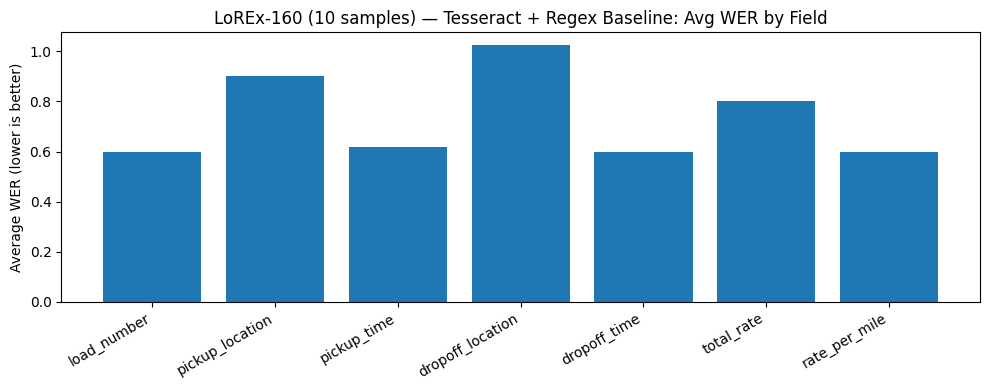

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/results/regex_tesseract_10.csv")

FIELDS = ["load_number","pickup_location","pickup_time","dropoff_location","dropoff_time","total_rate","rate_per_mile"]

avg_wer = [df[f"WER_{f}"].mean() for f in FIELDS]

plt.figure(figsize=(10,4))
plt.bar(FIELDS, avg_wer)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Average WER (lower is better)")
plt.title("LoREx-160 (10 samples) — Tesseract + Regex Baseline: Avg WER by Field")
plt.tight_layout()
plt.show()

Bar chart: average CER per field

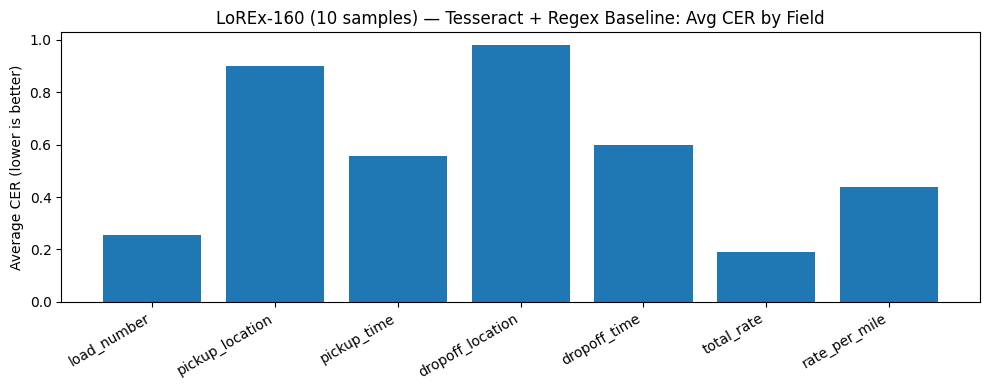

In [51]:
avg_cer = [df[f"CER_{f}"].mean() for f in FIELDS]

plt.figure(figsize=(10,4))
plt.bar(FIELDS, avg_cer)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Average CER (lower is better)")
plt.title("LoREx-160 (10 samples) — Tesseract + Regex Baseline: Avg CER by Field")
plt.tight_layout()
plt.show()

Heatmap Style Table

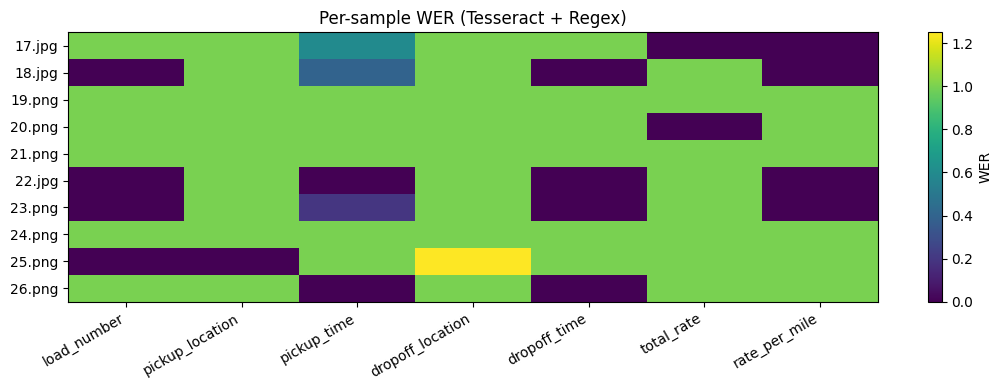

In [52]:
import numpy as np

wer_cols = [f"WER_{f}" for f in FIELDS]
M = df[wer_cols].to_numpy()

plt.figure(figsize=(11,4))
plt.imshow(M, aspect="auto")
plt.colorbar(label="WER")
plt.yticks(range(len(df)), df["image"])
plt.xticks(range(len(FIELDS)), FIELDS, rotation=30, ha="right")
plt.title("Per-sample WER (Tesseract + Regex)")
plt.tight_layout()
plt.show()

In [53]:
plt.savefig("/content/results/avg_wer.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [54]:
%cd /content/lorex-ocr-llm-experiments
!ls

/content/lorex-ocr-llm-experiments
notebooks  results


In [55]:
%cd /content
!ls

/content
drive  LoREx-160  lorex-ocr-llm-experiments  results  sample_data


In [56]:
%cd /content
!git clone https://github.com/ehs9nino/lorex-ocr-llm-experiments.git
%cd lorex-ocr-llm-experiments
!ls

/content
fatal: destination path 'lorex-ocr-llm-experiments' already exists and is not an empty directory.
/content/lorex-ocr-llm-experiments
notebooks  results


In [57]:
!git config --global user.name "Ehsan Qader"
!git config --global user.email "eqader@hse.ru"

In [58]:
!mkdir -p results
!cp /content/results/* results/
!ls results

avg_wer.png  regex_tesseract_10_avg.json  regex_tesseract_10.csv


In [59]:
from pathlib import Path

# path where your notebook is stored in Drive
NOTEBOOK_SRC = Path("/content/drive/MyDrive/Colab Notebooks/exp_01_regex_baseline.ipynb")

# repo folder
REPO_ROOT = Path("/content/lorex-ocr-llm-experiments")
(REPO_ROOT / "notebooks").mkdir(exist_ok=True)

# copy notebook
import shutil
shutil.copy(NOTEBOOK_SRC, REPO_ROOT / "notebooks" / "exp_01_regex_baseline.ipynb")

print("Notebook copied.")

Notebook copied.


In [1]:
a=12;
b=12;
c=a+b;

print(c)

24
